In [1]:
import pandas as pd
import numpy as np 
import os
import seaborn as sns
from tqdm import tqdm
import time
import requests
import matplotlib.pyplot as plt

file_path_d = r"C:\Users\ADMIN\DME Dropbox\Park YR\project\Business Process Mining"

In [2]:
test = os.path.join(file_path_d, 'data','G01_eventlog.tsv')
test = pd.read_csv(test, sep='\t')
test

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_31620\3212364033.py:2: DtypeWarning: Columns (0: application_number) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(test, sep='\t')


,Unnamed: 0,application_number,event_code,recorded_date,event_desc,event_order
0,0,3757645,FLRCPT.O,1981-12-18,Filing Receipt,1
1,1,3757645,L132,1981-12-18,Secrecy Order Imposed,2
2,2,3757645,L133,1982-07-22,Secrecy Order Renewed,3
3,3,3757645,L133,1983-07-19,Secrecy Order Renewed,4
4,4,3757645,L133,1984-07-19,Secrecy Order Renewed,5
...,...,...,...,...,...,...
507392076,507392076,PCT/ZA22/50013,MP210,2022-05-23,Mail International Search Report,15
507392077,507392077,PCT/ZA22/50013,MICR,2022-07-22,Applicant Has Filed a Verified Statement of Mi...,16
507392078,507392078,PCT/ZA22/50013,SMAL,2022-07-22,Applicant Has Filed a Verified Statement of Sm...,17
507392079,507392079,PCT/ZA22/50013,P224,2022-08-17,General Communication - No Other Forms Applicable,18


In [3]:
check = test.groupby('event_desc')['application_number'].nunique()
check

event_desc
1.501 Submission by Patent Owner                                            146
1.501 Submission by Third Party                                              88
1.55/1.78 Indicator set                                                   35592
1.55/1.78 statement retracted                                              1763
102P                                                                       1514
                                                                          ...  
terminal disclaimer fee paid                                              35427
to Close the A/R Record and Reset the Status for Expired Suspensions.     15893
track 1 OFF                                                              117914
track 1 ON                                                                69191
transaction for FDA Determination of Regulatory Review Period              1378
Name: application_number, Length: 1941, dtype: int64

=== RAW full log: 507,392,081 rows, 14,071,511 cases ===



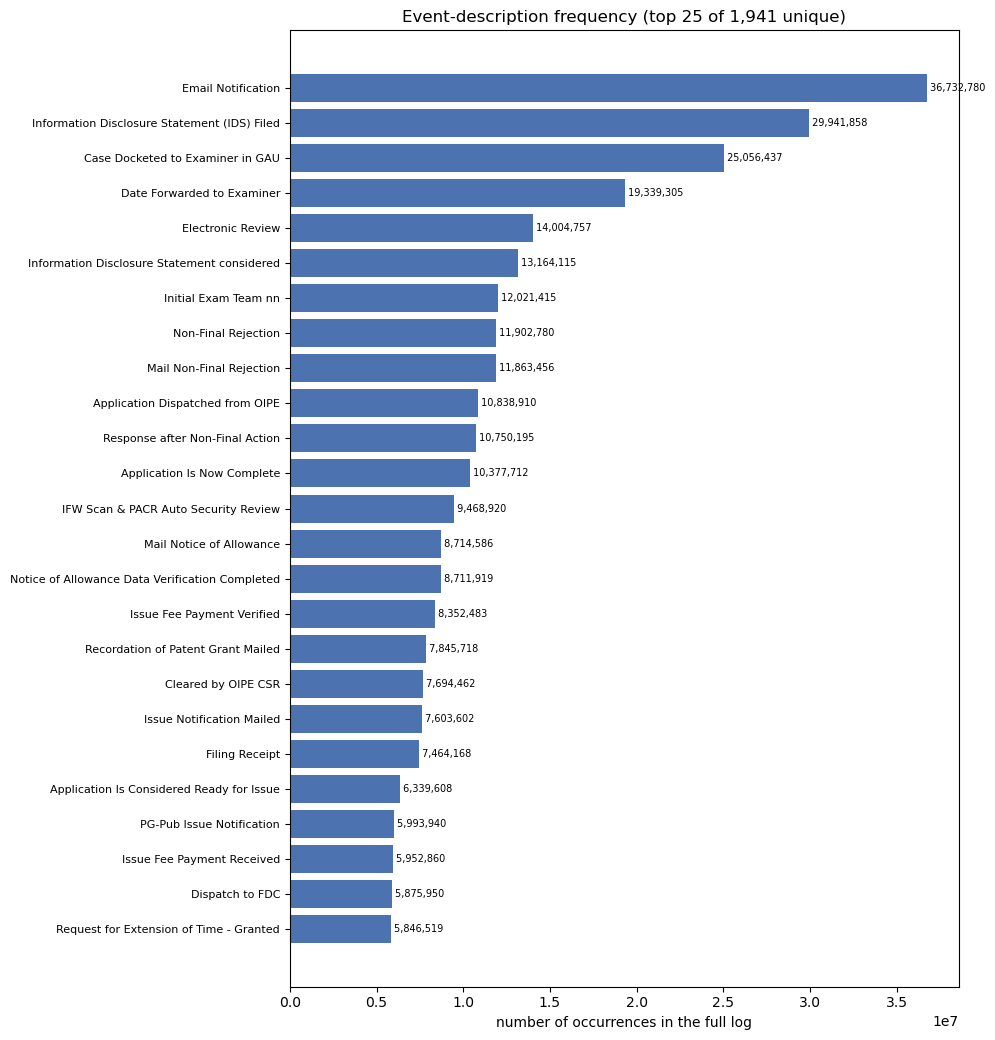

saved -> desc_freq.png
  total events: 507,392,081 | unique descriptions: 1,941



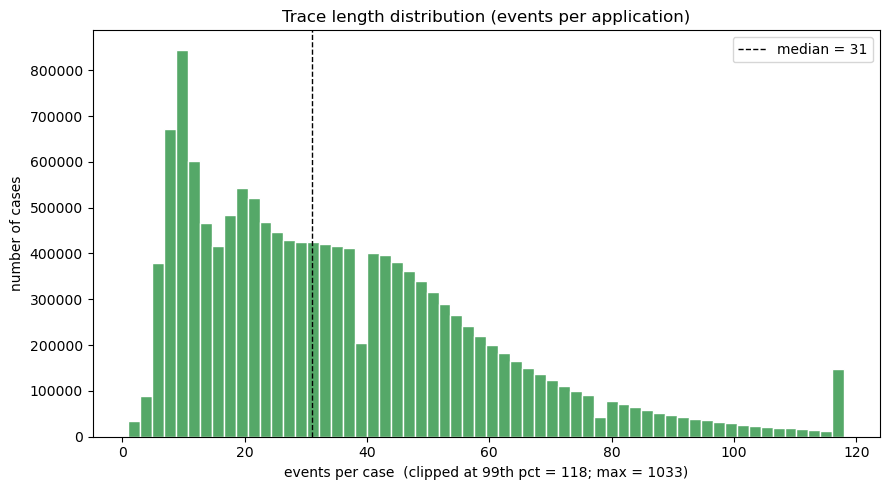

saved -> trace_length.png
  cases: 14,071,511 | median length: 31 | mean: 36.1 | max: 1033



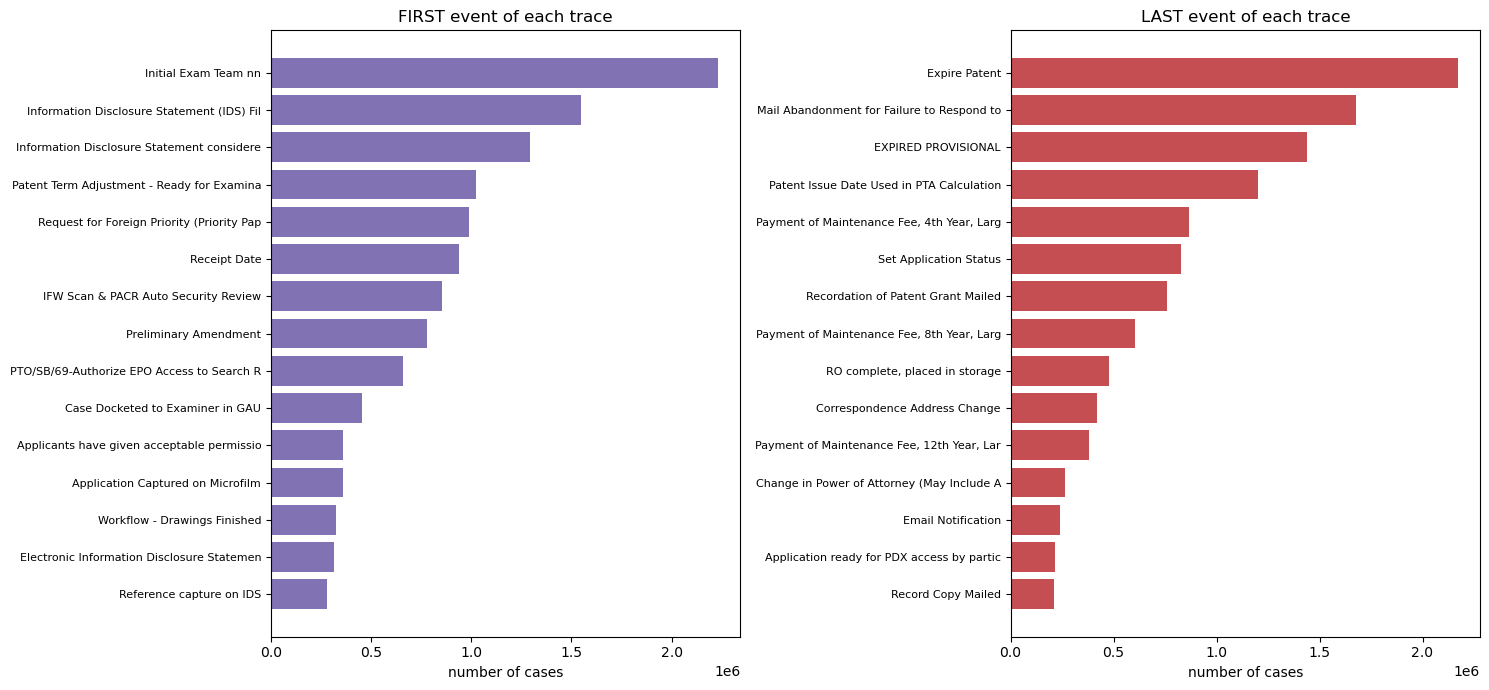

saved -> first_last_event.png
  top first events: ['Initial Exam Team nn', 'Information Disclosure Statement (IDS) Filed', 'Information Disclosure Statement considered']
  top last events : ['Expire Patent', 'Mail Abandonment for Failure to Respond to Office Action', 'EXPIRED PROVISIONAL']



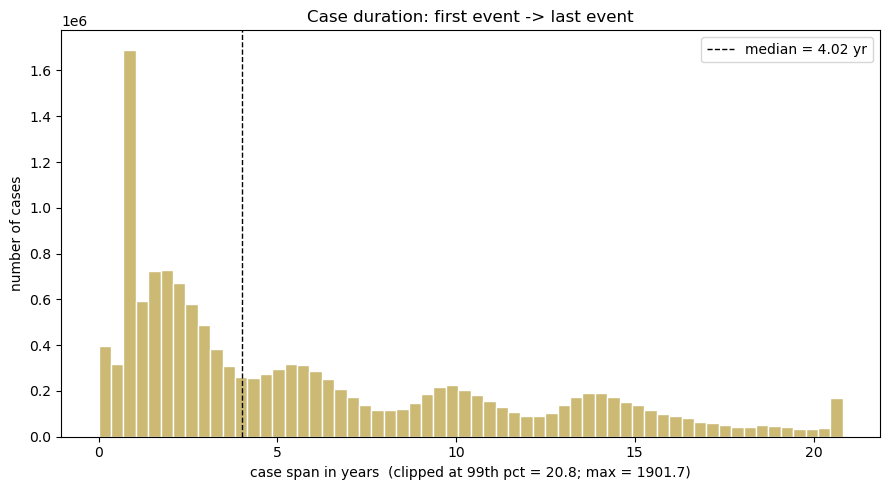

saved -> case_duration.png
  median span: 4.02 yr | mean: 6.05 yr | max: 1901.7 yr



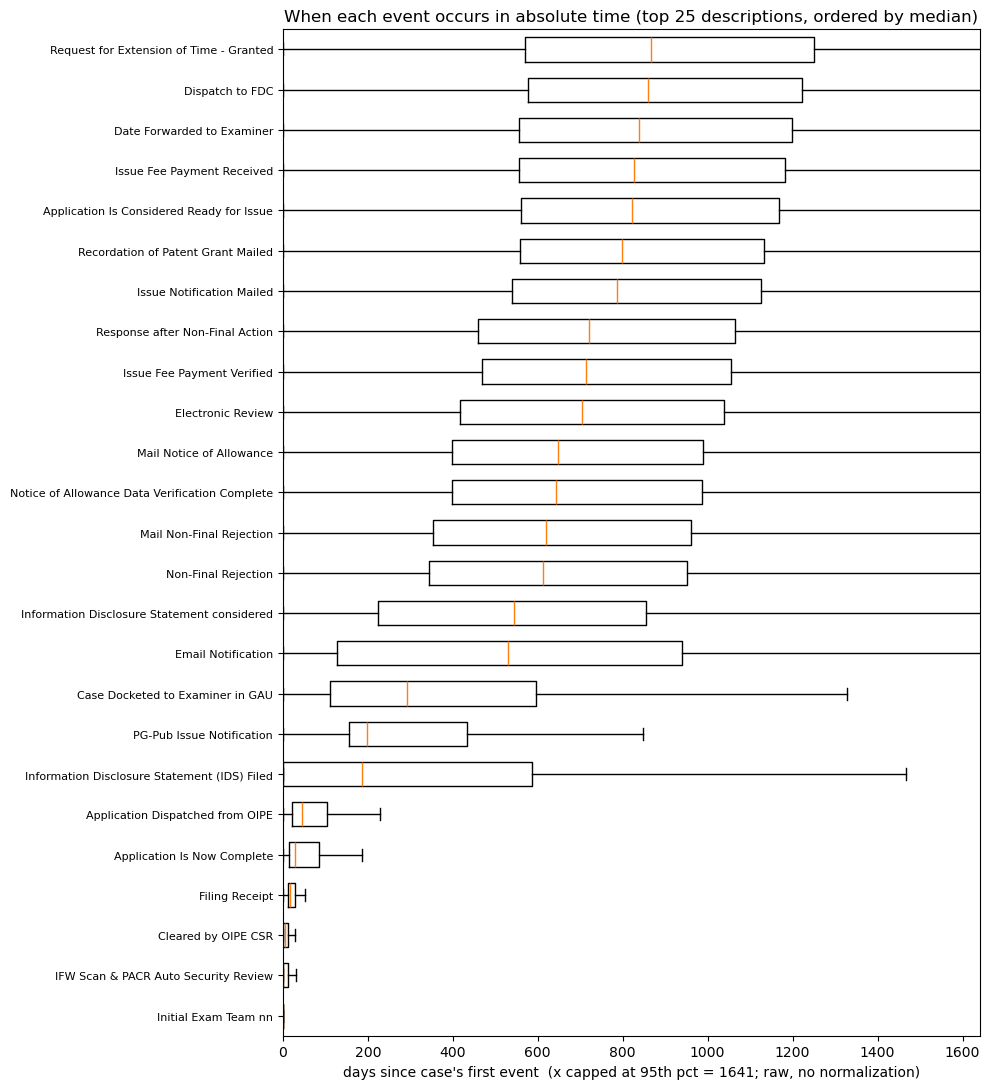

saved -> event_timing.png


,Unnamed: 0,application_number,event_code,recorded_date,event_desc,event_order
0,0,3757645,FLRCPT.O,1981-12-18,Filing Receipt,1
1,1,3757645,L132,1981-12-18,Secrecy Order Imposed,2
2,2,3757645,L133,1982-07-22,Secrecy Order Renewed,3
3,3,3757645,L133,1983-07-19,Secrecy Order Renewed,4
4,4,3757645,L133,1984-07-19,Secrecy Order Renewed,5
...,...,...,...,...,...,...
507392076,507392076,PCT/ZA22/50013,MP210,2022-05-23,Mail International Search Report,15
507392077,507392077,PCT/ZA22/50013,MICR,2022-07-22,Applicant Has Filed a Verified Statement of Mi...,16
507392078,507392078,PCT/ZA22/50013,SMAL,2022-07-22,Applicant Has Filed a Verified Statement of Sm...,17
507392079,507392079,PCT/ZA22/50013,P224,2022-08-17,General Communication - No Other Forms Applicable,18


In [4]:
"""
Descriptive views of the RAW full event log.

No manipulation: no granted-only filter, no truncation at grant, no position
normalization, no entropy/coverage. Just what the data looks like as-is.

Plots (each saved as its own PNG):
    1. desc_freq.png        event-description frequency (top N)
    2. trace_length.png     number of events per case (distribution)
    3. first_last_event.png what each trace starts and ends with (top N)
    4. case_duration.png    first-event -> last-event span per case (years)
    5. event_timing.png     raw days-since-case-start per event, top N descriptions (boxplot)

Set the 4 column names below, then call:  run_all(test)
where `test` is your FULL log dataframe.
"""



# ============================================================
# CONFIG  -- match your full-log dataframe
# ============================================================
CASE = "application_number"
DATE = "recorded_date"
DESC = "event_desc"
SEQ  = "event_order"

TOP_N = 25          # how many descriptions to show in the bar/boxplot views


# ------------------------------------------------------------
def _load(df):
    """Light parse only: datetime + numeric order. No row filtering beyond unparseable keys."""
    df = df.copy()
    df[DATE] = pd.to_datetime(df[DATE], errors="coerce")
    df[SEQ]  = pd.to_numeric(df[SEQ], errors="coerce")
    return df


# ============================================================
# 1. event-description frequency (top N)
# ============================================================
def plot_desc_frequency(df, top_n=TOP_N, out="desc_freq.png"):
    vc = df[DESC].value_counts()
    top = vc.head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 0.38 * len(top) + 1))
    ax.barh(range(len(top)), top.values, color="#4C72B0")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([str(s)[:50] for s in top.index], fontsize=8)
    ax.set_xlabel("number of occurrences in the full log")
    ax.set_title(f"Event-description frequency (top {top_n} of {df[DESC].nunique():,} unique)")
    for i, v in enumerate(top.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=7)
    plt.tight_layout(); plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"saved -> {out}")
    print(f"  total events: {len(df):,} | unique descriptions: {df[DESC].nunique():,}")
    return fig


# ============================================================
# 2. trace length per case
# ============================================================
def plot_trace_length(df, out="trace_length.png"):
    lengths = df.groupby(CASE).size()

    fig, ax = plt.subplots(figsize=(9, 5))
    upper = int(lengths.quantile(0.99))
    ax.hist(lengths.clip(upper=upper), bins=min(60, upper), color="#55A868", edgecolor="white")
    ax.set_xlabel(f"events per case  (clipped at 99th pct = {upper}; max = {lengths.max()})")
    ax.set_ylabel("number of cases")
    ax.set_title("Trace length distribution (events per application)")
    ax.axvline(lengths.median(), color="k", ls="--", lw=1,
               label=f"median = {lengths.median():.0f}")
    ax.legend()
    plt.tight_layout(); plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"saved -> {out}")
    print(f"  cases: {lengths.size:,} | median length: {lengths.median():.0f} | "
          f"mean: {lengths.mean():.1f} | max: {lengths.max()}")
    return fig


# ============================================================
# 3. first / last event of each trace
# ============================================================
def plot_first_last(df, top_n=15, out="first_last_event.png"):
    s = df.sort_values([CASE, SEQ])
    first = s.groupby(CASE)[DESC].first().value_counts().head(top_n).iloc[::-1]
    last  = s.groupby(CASE)[DESC].last().value_counts().head(top_n).iloc[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 0.40 * top_n + 1))
    for ax, data, title, color in [
        (axes[0], first, "FIRST event of each trace", "#8172B3"),
        (axes[1], last,  "LAST event of each trace",  "#C44E52"),
    ]:
        ax.barh(range(len(data)), data.values, color=color)
        ax.set_yticks(range(len(data)))
        ax.set_yticklabels([str(x)[:42] for x in data.index], fontsize=8)
        ax.set_xlabel("number of cases")
        ax.set_title(title)
    plt.tight_layout(); plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"saved -> {out}")
    print("  top first events:", list(first.index[::-1][:3]))
    print("  top last events :", list(last.index[::-1][:3]))
    return fig


# ============================================================
# 4. case duration (first -> last event)
# ============================================================
def plot_case_duration(df, out="case_duration.png"):
    d = df.dropna(subset=[DATE]).groupby(CASE)[DATE].agg(["min", "max"])
    years = (d["max"] - d["min"]).dt.days / 365.25

    fig, ax = plt.subplots(figsize=(9, 5))
    upper = float(years.quantile(0.99))
    ax.hist(years.clip(upper=upper), bins=60, color="#CCB974", edgecolor="white")
    ax.set_xlabel(f"case span in years  (clipped at 99th pct = {upper:.1f}; max = {years.max():.1f})")
    ax.set_ylabel("number of cases")
    ax.set_title("Case duration: first event -> last event")
    ax.axvline(years.median(), color="k", ls="--", lw=1,
               label=f"median = {years.median():.2f} yr")
    ax.legend()
    plt.tight_layout(); plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"saved -> {out}")
    print(f"  median span: {years.median():.2f} yr | mean: {years.mean():.2f} yr | max: {years.max():.1f} yr")
    return fig


# ============================================================
# 5. raw event timing: days since each case's first event (top N descriptions)
# ============================================================
def plot_event_timing(df, top_n=TOP_N, out="event_timing.png"):
    d = df.dropna(subset=[DATE]).copy()
    d["days"] = (d[DATE] - d.groupby(CASE)[DATE].transform("min")).dt.days

    keep = d[DESC].value_counts().head(top_n).index
    sub = d[d[DESC].isin(keep)]
    order = sub.groupby(DESC)["days"].median().sort_values().index   # early -> late by median day
    data = [sub.loc[sub[DESC] == name, "days"].to_numpy() for name in order]

    fig, ax = plt.subplots(figsize=(10, 0.40 * len(order) + 1))
    ax.boxplot(data, vert=False, showfliers=False, widths=0.6)
    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels([str(x)[:46] for x in order], fontsize=8)
    cap = float(np.percentile(np.concatenate(data), 95))
    ax.set_xlim(0, cap)
    ax.set_xlabel(f"days since case's first event  (x capped at 95th pct = {cap:.0f}; raw, no normalization)")
    ax.set_title(f"When each event occurs in absolute time (top {top_n} descriptions, ordered by median)")
    plt.tight_layout(); plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"saved -> {out}")
    return fig


# ============================================================
# run all
# ============================================================
def run_all(df):
    df = _load(df)
    print(f"=== RAW full log: {len(df):,} rows, {df[CASE].nunique():,} cases ===\n")
    plot_desc_frequency(df); print()
    plot_trace_length(df);   print()
    plot_first_last(df);     print()
    plot_case_duration(df);  print()
    plot_event_timing(df)
    return df


# ============================================================
# Execute  (replace `test` with your full event log dataframe)
# ============================================================
run_all(test)

In [5]:
"""
Start-anchor diagnostic on the RAW full log.

Question: can we use 'Filing Receipt' as the trace start (e1)?
To decide, we need to know, per case:
  - does it appear at all?  (coverage)
  - if so, how many times?
  - is it the FIRST event by order?  is it the EARLIEST by date?
  - for cases that lack it, what do they start with instead?

No truncation, no normalization. Pure inspection of the raw log.
Set the column names, then call:  diagnose(test)
"""

import numpy as np
import pandas as pd

CASE = "application_number"
DATE = "recorded_date"
DESC = "event_desc"
SEQ  = "event_order"

# Primary anchor to test, plus a small family of filing-related fallbacks to compare.
PRIMARY_ANCHOR = "Filing Receipt"
FAMILY_REGEX   = r"filing receipt|^receipt date$"   # case-insensitive; broadens the check


def _prep(df):
    df = df.copy()
    df[DATE] = pd.to_datetime(df[DATE], errors="coerce")
    df[SEQ]  = pd.to_numeric(df[SEQ], errors="coerce")
    df = df.dropna(subset=[CASE, SEQ])
    return df.sort_values([CASE, SEQ]).reset_index(drop=True)


def _anchor_report(df, mask, name, n_cases):
    """For rows selected by `mask`, report coverage / multiplicity / position as a start anchor."""
    sub = df[mask]
    if sub.empty:
        print(f"  [{name}] never appears in the log.")
        return

    # coverage: cases containing the anchor at least once
    cases_with = sub[CASE].nunique()
    cov = cases_with / n_cases

    # occurrences per case (where present)
    occ = sub.groupby(CASE).size()

    # rank of the FIRST anchor occurrence within each case's order sequence (1 = first event)
    first_anchor = sub.groupby(CASE)[SEQ].min().rename("anchor_order")
    case_min_seq  = df.groupby(CASE)[SEQ].min().rename("case_min_seq")
    case_min_date = df.dropna(subset=[DATE]).groupby(CASE)[DATE].min().rename("case_min_date")
    first_anchor_date = (sub.dropna(subset=[DATE]).sort_values([CASE, SEQ])
                            .groupby(CASE)[DATE].first().rename("anchor_date"))

    j = pd.concat([first_anchor, case_min_seq, case_min_date, first_anchor_date], axis=1).dropna(subset=["anchor_order"])
    is_first_by_order = (j["anchor_order"] == j["case_min_seq"]).mean()
    is_earliest_date  = (j["anchor_date"] == j["case_min_date"]).mean()
    # how many events sit BEFORE the anchor (order rank of anchor minus 1)
    rank = (df[df[CASE].isin(first_anchor.index)]
              .merge(first_anchor, on=CASE)
              .assign(before=lambda x: x[SEQ] < x["anchor_order"])
              .groupby(CASE)["before"].sum())

    print(f"  [{name}]")
    print(f"     coverage (cases with >=1)        : {cov:6.2%}   ({cases_with:,} / {n_cases:,} cases)")
    print(f"     occurrences/case  median (max)   : {occ.median():.0f}  ({occ.max()})")
    print(f"     is the FIRST event (by order)    : {is_first_by_order:6.2%}")
    print(f"     is the EARLIEST event (by date)  : {is_earliest_date:6.2%}")
    print(f"     events before it  median (max)   : {rank.median():.0f}  ({rank.max()})")


def diagnose(df):
    df = _prep(df)
    n_cases = df[CASE].nunique()
    print(f"=== RAW log: {len(df):,} rows, {n_cases:,} cases ===\n")

    print("ANCHOR CANDIDATES")
    _anchor_report(df, df[DESC] == PRIMARY_ANCHOR, f"exact '{PRIMARY_ANCHOR}'", n_cases)
    print()
    _anchor_report(df, df[DESC].str.contains(FAMILY_REGEX, case=False, na=False),
                   f"filing family  (regex: {FAMILY_REGEX})", n_cases)

    # What actually starts each trace (first event by order)?
    print("\nACTUAL FIRST EVENT OF EACH TRACE  (top 15)")
    first_ev = df.groupby(CASE)[DESC].first()
    print((first_ev.value_counts(normalize=True).head(15) * 100).round(2).to_string())

    # For cases WITHOUT the exact primary anchor: how many, and what do they start with?
    has_anchor = set(df.loc[df[DESC] == PRIMARY_ANCHOR, CASE].unique())
    without = df[~df[CASE].isin(has_anchor)]
    n_without = without[CASE].nunique()
    print(f"\nCASES WITHOUT '{PRIMARY_ANCHOR}': {n_without:,} ({n_without/n_cases:.2%})")
    if n_without:
        print("  they start with (top 10):")
        print((without.groupby(CASE)[DESC].first().value_counts(normalize=True).head(10) * 100)
              .round(2).to_string())

    return df


# ============================================================
# Execute  (replace `test` with your full event log dataframe)
# ============================================================
diagnose(test)

=== RAW log: 507,392,081 rows, 14,071,511 cases ===

ANCHOR CANDIDATES
  [exact 'Filing Receipt']
     coverage (cases with >=1)        : 52.45%   (7,380,378 / 14,071,511 cases)
     occurrences/case  median (max)   : 1  (29)
     is the FIRST event (by order)    :  0.00%
     is the EARLIEST event (by date)  :  0.00%
     events before it  median (max)   : 11  (953)



KeyboardInterrupt: 

In [23]:
test.columns

Index(['Unnamed: 0', 'application_number', 'event_code', 'recorded_date',
       'event_desc', 'event_order'],
      dtype='str')

group sizes:
 group
with FR       7380378
without FR    6691133
Name: count, dtype: int64 

grant rate by group:
 group
with FR       0.141
without FR    0.137
Name: granted, dtype: float64 

start_year median:
 group
with FR       2015.0
without FR    2000.0
Name: start_year, dtype: float64 

time-to-grant (yr) median:
 group
with FR       1.89
without FR    1.20
Name: ttg_years, dtype: float64


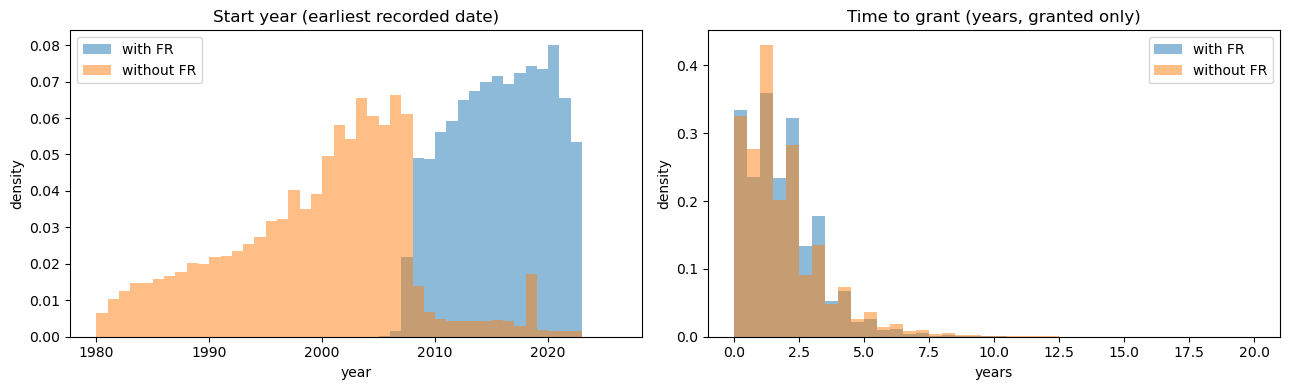

In [24]:
CASE, DATE, DESC = "application_number", "recorded_date", "event_desc"
ANCHOR = "Filing Receipt"
GRANT  = {"Recordation of Patent Grant Mailed", "Recordation of Patent eGrant"}

df = test.copy()                                   # test = 전체 로그
df[DATE] = pd.to_datetime(df[DATE], errors="coerce")

# --- case 단위 테이블: 그룹 / 시작연도(최초기록 근사) / grant까지 시간 ---
has_fr = df.loc[df[DESC] == ANCHOR, CASE].unique()
case = pd.DataFrame({CASE: df[CASE].unique()})
case["group"] = np.where(case[CASE].isin(has_fr), "with FR", "without FR")

start = df.dropna(subset=[DATE]).groupby(CASE)[DATE].min().rename("start")          # 최초 기록일(공통 잣대)
grant = df[df[DESC].isin(GRANT)].dropna(subset=[DATE]).groupby(CASE)[DATE].min().rename("grant")
case = case.merge(start, on=CASE, how="left").merge(grant, on=CASE, how="left")
case["start_year"] = case["start"].dt.year
case["ttg_years"]  = (case["grant"] - case["start"]).dt.days / 365.25
case["granted"]    = case["grant"].notna()

# --- 숫자 요약 ---
print("group sizes:\n", case["group"].value_counts(), "\n")
print("grant rate by group:\n", case.groupby("group")["granted"].mean().round(3), "\n")
print("start_year median:\n", case.groupby("group")["start_year"].median(), "\n")
print("time-to-grant (yr) median:\n",
      case[case.granted].groupby("group")["ttg_years"].median().round(2))

# --- 분포 비교 그림 2장 ---
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for grp, sub in case.groupby("group"):
    ax[0].hist(sub["start_year"].dropna(), bins=range(1980, 2027),
               density=True, alpha=0.5, label=grp)
ax[0].set_title("Start year (earliest recorded date)"); ax[0].set_xlabel("year")
ax[0].set_ylabel("density"); ax[0].legend()

g = case[case.granted & case.ttg_years.between(0, 20)]
for grp, sub in g.groupby("group"):
    ax[1].hist(sub["ttg_years"], bins=40, density=True, alpha=0.5, label=grp)
ax[1].set_title("Time to grant (years, granted only)"); ax[1].set_xlabel("years")
ax[1].set_ylabel("density"); ax[1].legend()
plt.tight_layout(); plt.savefig("fr_bias_check.png", dpi=150, bbox_inches="tight"); plt.show()

In [6]:
CASE   = "application_number"
DESC   = "event_desc"
ANCHOR = "Filing Receipt"

# Filing Receipt가 있는 case의 application_number 집합
has_fr = test.loc[test[DESC] == ANCHOR, CASE].unique()

# 그 case들의 모든 이벤트만 남긴 새 df
df_fr = test[test[CASE].isin(has_fr)].copy()

# --- sanity check ---
print(f"cases : {test[CASE].nunique():,} -> {df_fr[CASE].nunique():,} "
      f"({df_fr[CASE].nunique()/test[CASE].nunique():.1%})")
print(f"rows  : {len(test):,} -> {len(df_fr):,} "
      f"({len(df_fr)/len(test):.1%})")

cases : 14,071,511 -> 7,380,378 (52.4%)
rows  : 507,392,081 -> 325,728,827 (64.2%)


In [7]:
df_fr

,Unnamed: 0,application_number,event_code,recorded_date,event_desc,event_order
0,0,3757645,FLRCPT.O,1981-12-18,Filing Receipt,1
1,1,3757645,L132,1981-12-18,Secrecy Order Imposed,2
2,2,3757645,L133,1982-07-22,Secrecy Order Renewed,3
3,3,3757645,L133,1983-07-19,Secrecy Order Renewed,4
4,4,3757645,L133,1984-07-19,Secrecy Order Renewed,5
...,...,...,...,...,...,...
492671960,492671960,96000055,MRSEN,2015-11-16,SE - Mail Notice of Intent to Issue Reexam Cer...,27
492671961,492671961,96000055,MREXN,2015-12-01,RX - Mail Examiner Interview Summary Record,28
492671962,492671962,96000055,MRSEN,2015-12-01,SE - Mail Notice of Intent to Issue Reexam Cer...,29
492671963,492671963,96000055,REEX,2015-12-04,Input Issue Number and Issue Date for Reexamin...,30


cases: 7,380,378 | rows: 325,728,827


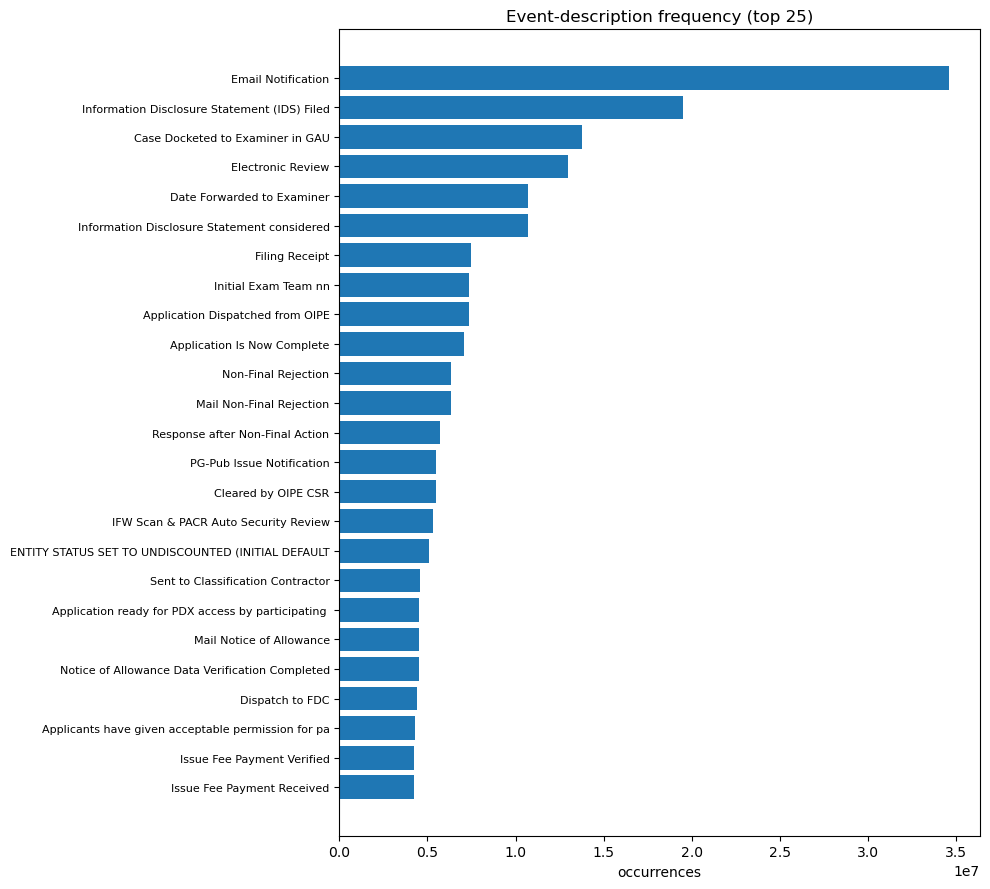

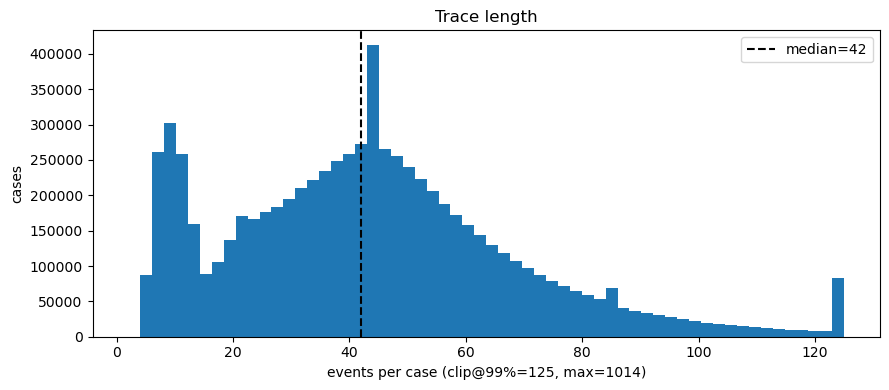

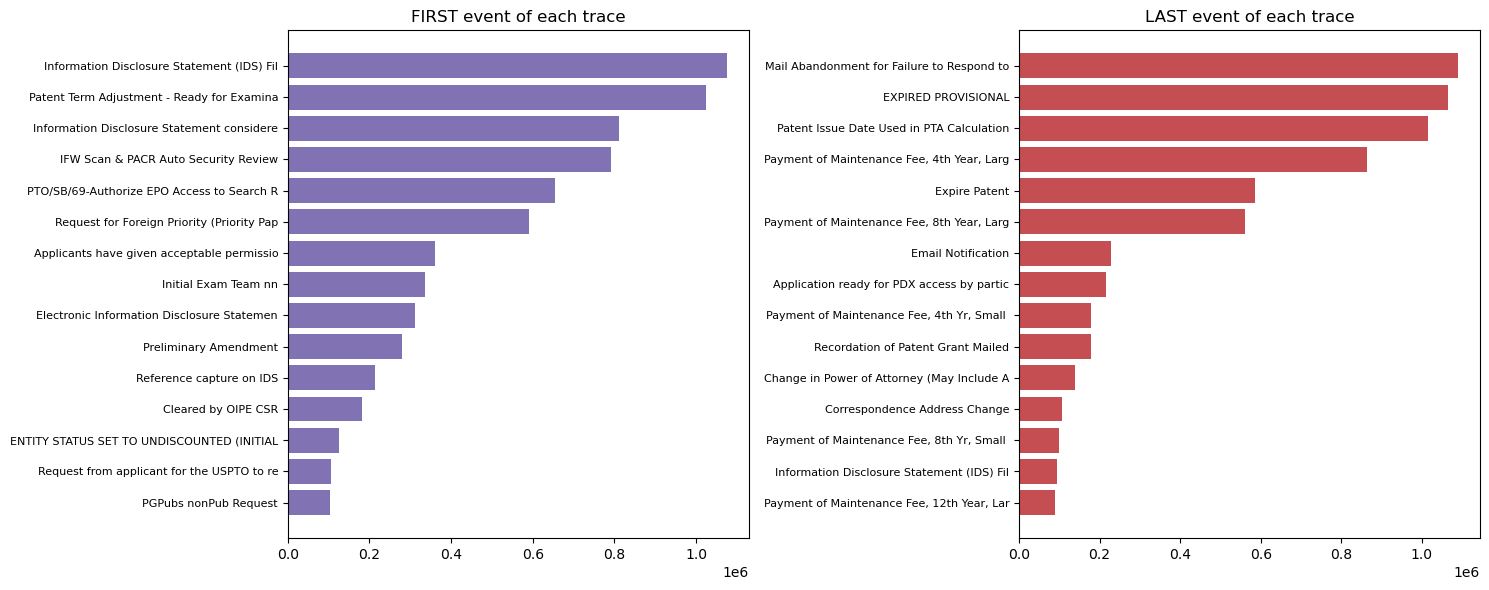


FIRST event top 5:
 event_desc
Information Disclosure Statement (IDS) Filed        14.57
Patent Term Adjustment - Ready for Examination      13.87
Information Disclosure Statement considered         11.01
IFW Scan & PACR Auto Security Review                10.72
PTO/SB/69-Authorize EPO Access to Search Results     8.87
Name: proportion, dtype: float64

LAST event top 5:
 event_desc
Mail Abandonment for Failure to Respond to Office Action    14.77
EXPIRED PROVISIONAL                                         14.43
Patent Issue Date Used in PTA Calculation                   13.74
Payment of Maintenance Fee, 4th Year, Large Entity          11.69
Expire Patent                                                7.92
Name: proportion, dtype: float64


In [9]:
d = df_fr.copy()
d[DATE] = pd.to_datetime(d[DATE], errors="coerce")
d[SEQ]  = pd.to_numeric(d[SEQ], errors="coerce")
d = d.sort_values([CASE, SEQ])

print(f"cases: {d[CASE].nunique():,} | rows: {len(d):,}")

# 1) description 빈도 top 25
vc = d[DESC].value_counts().head(25).iloc[::-1]
plt.figure(figsize=(10, 9))
plt.barh(range(len(vc)), vc.values)
plt.yticks(range(len(vc)), [s[:50] for s in vc.index], fontsize=8)
plt.xlabel("occurrences"); plt.title("Event-description frequency (top 25)")
plt.tight_layout(); plt.show()

# 2) trace 길이 분포
lengths = d.groupby(CASE).size()
plt.figure(figsize=(9, 4))
up = int(lengths.quantile(0.99))
plt.hist(lengths.clip(upper=up), bins=60)
plt.axvline(lengths.median(), color="k", ls="--", label=f"median={lengths.median():.0f}")
plt.xlabel(f"events per case (clip@99%={up}, max={lengths.max()})"); plt.ylabel("cases")
plt.title("Trace length"); plt.legend(); plt.tight_layout(); plt.show()

# 3) 첫 / 마지막 이벤트 top 15  ← 가장 보고 싶었던 것
first = d.groupby(CASE)[DESC].first().value_counts().head(15).iloc[::-1]
last  = d.groupby(CASE)[DESC].last().value_counts().head(15).iloc[::-1]
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].barh(range(len(first)), first.values, color="#8172B3")
ax[0].set_yticks(range(len(first))); ax[0].set_yticklabels([s[:42] for s in first.index], fontsize=8)
ax[0].set_title("FIRST event of each trace")
ax[1].barh(range(len(last)), last.values, color="#C44E52")
ax[1].set_yticks(range(len(last))); ax[1].set_yticklabels([s[:42] for s in last.index], fontsize=8)
ax[1].set_title("LAST event of each trace")
plt.tight_layout(); plt.show()

print("\nFIRST event top 5:\n", d.groupby(CASE)[DESC].first().value_counts(normalize=True).head().mul(100).round(2))
print("\nLAST event top 5:\n",  d.groupby(CASE)[DESC].last().value_counts(normalize=True).head().mul(100).round(2))

Filing Receipt 앞 '기간(일)' 분포:
count    1813322.0
mean          23.4
std          416.6
min            0.0
50%           14.0
75%           20.0
90%           28.0
95%           37.0
99%          335.0
max       474801.0
Name: days_before_fr, dtype: float64

Filing Receipt 앞 '이벤트 수' 분포:
count    1813322.0
mean          10.6
std            4.0
min            0.0
50%           11.0
75%           13.0
90%           15.0
95%           16.0
99%           20.0
max          821.0
Name: events_before_fr, dtype: float64

앞 기간이 0일인 case 비율: 7.1%
앞 기간이 30일 이하 case 비율: 92.1%


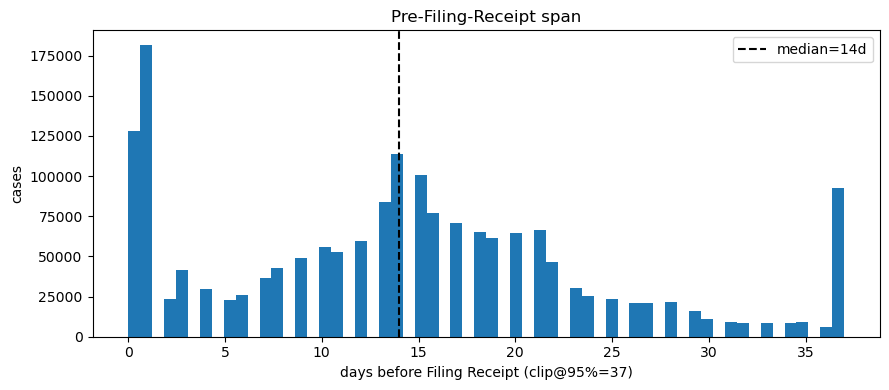

In [10]:
CASE, DATE, DESC, SEQ = "application_number", "recorded_date", "event_desc", "event_order"
ANCHOR = "Filing Receipt"

d = df_fr.copy()
d[DATE] = pd.to_datetime(d[DATE], errors="coerce")
d[SEQ]  = pd.to_numeric(d[SEQ], errors="coerce")

# 각 case의 최소 날짜, 그리고 Filing Receipt(첫 발생) 날짜·순번
case_min_date = d.dropna(subset=[DATE]).groupby(CASE)[DATE].min().rename("min_date")
fr = (d[d[DESC] == ANCHOR].sort_values([CASE, SEQ])
        .groupby(CASE).first()[[DATE, SEQ]]
        .rename(columns={DATE: "fr_date", SEQ: "fr_order"}))
case_min_seq = d.groupby(CASE)[SEQ].min().rename("min_seq")

j = pd.concat([case_min_date, fr, case_min_seq], axis=1).dropna()
j["days_before_fr"]   = (j["fr_date"] - j["min_date"]).dt.days   # ← Filing Receipt 앞 기간
j["events_before_fr"] = j["fr_order"] - j["min_seq"]             # ← 앞에 깔린 이벤트 수

print("Filing Receipt 앞 '기간(일)' 분포:")
print(j["days_before_fr"].describe(percentiles=[.5,.75,.9,.95,.99]).round(1))
print("\nFiling Receipt 앞 '이벤트 수' 분포:")
print(j["events_before_fr"].describe(percentiles=[.5,.75,.9,.95,.99]).round(1))
print(f"\n앞 기간이 0일인 case 비율: {(j['days_before_fr']==0).mean():.1%}")
print(f"앞 기간이 30일 이하 case 비율: {(j['days_before_fr']<=30).mean():.1%}")

import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
up = int(j["days_before_fr"].quantile(0.95))
plt.hist(j["days_before_fr"].clip(lower=0, upper=up), bins=60)
plt.axvline(j["days_before_fr"].median(), color="k", ls="--",
            label=f"median={j['days_before_fr'].median():.0f}d")
plt.xlabel(f"days before Filing Receipt (clip@95%={up})"); plt.ylabel("cases")
plt.title("Pre-Filing-Receipt span"); plt.legend(); plt.tight_layout(); plt.show()